# Fully Fine-tuning a SLM with SFT 🤗

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/'Learning 📚'/'YouTube ▶️'/'Daniel Bourke'/'gemma3-270m-mermaid'

Mounted at /content/drive
/content/drive/MyDrive/Learning 📚/YouTube ▶️/Daniel Bourke/gemma3-270m-mermaid


## Overview

### Why fine-tune a SLM?

Because we want small model for a **specific task** and if we have our own model... we can **run it locally** and everywhere we like (i.e. don't pay API credits or leak our data online).

### How to do supervised fine-tuning on an LLM?

There are several ways to fine-tune an LLM including reinforcement learning (RL) and Supervised Fine-tuning (SFT).

We are going to do SFT because it's the most straightforward.

Basically SFT = give samples of inputs and outputs and the model learns to map a given input to a given output.

For example if our goal was to extract names:
- Input: Hello my name is Daniel
- Output: Daniel

### LLM Fine-tuning Mindset

- In LLM world, data inputs are tokens and data outputs are tokens.
- A token is a numerical representation of some kind of data.
- Computers like numbers (not images, text, videos, etc).
- Everything must be turned into numbers.
- And data = a very broad term.
- It could be text, images, video (series of images), audio, DNA sequences, Excel spreadsheets, you name it.
- The goal of the LLM is to be given an input sequence of tokens and then predict the following tokens.

So with this mindset, you can think of any problem as **tokens in, tokens out**. Ask yourself: *What tokens do I want to put in and what tokens do I want my model to return?*

In our case, we want to put in almost any string input. And we want to get back structured information (mermaid diagrams). This a very specific use case, however, the beauty of LLMs being so general is that you can apply this tokens in, tokens out mindset to almost anything.

If you've got an existing dataset (no problem if you don't, you can create one), chances are, you can fine-tune an LLM to do pretty well on it.


### What we're cooking

We're going to build a custom SLM to generate Mermaid sequence diagrams from user prompts.

### Ingredients

1. Model ([Gemma-3-270M](https://huggingface.co/google/gemma-3-270m-it))
2. Datasets
  - [Training data](https://huggingface.co/datasets/Celiadraw/text-to-mermaid/viewer/default/train?row=0) (a pre-baked dataset of human-verified examples)
  - [Test data](https://huggingface.co/datasets/ibm-research/MermaidSeqBench) (a pre-baked dataset of human-verified examples)
3. Training code (Hugging Face Transformers + TRL)
4. Eval code
5. Demo

### Method

1. Download model - Hugging Face [`transformers`](https://huggingface.co/docs/transformers/index)
2. Download datasets - Hugging Face [`datasets`](https://huggingface.co/docs/datasets/en/index)
3. Inspect datasets - Hugging Face `datasets`
4. Train model on trainung set - Hugging Face [`trl`](https://huggingface.co/docs/trl/en/index) (TRL = Transformers Reinforcement Learning)
5. Eval model - basically just look at a bunch of samples from the test set
6. Create an interactive demo - Hugging Face `gradio`
7. Bonus: Make the demo public so other people can use it - Hugging Face Spaces

### Fine-tuning LLM vs RAG

- Fine-tuning &rarr; To do a very specific task, e.g. structured data extraction.
- RAG &rarr; You want to inject custom knowledge into an LLM.

### Why fine-tune your own model?

1. Own the model, can run on own hardware
2. Our task is simple enough to just use a small language model
3. No API calls needed
4. Can run in batch mode to get much faster inference than API calls
5. Model by default wasn't very good at our task but now since fine-tuning, is *very good*

### Definitions

Some quick definitions of what we're doing.

- **Full fine-tuning** - All weights on the model are updated. Often takes longer and requires larger hardware capacity, however, if your model is small enough (e.g. 270M parameter or less), you can often do full fine-tuning.
- **LoRA fine-tuning** (also known as partial fine-tuning) - [Low Rank Adaptation](https://arxiv.org/abs/2106.09685) or training a small adapter to attach to your original model. Requires significantly less resources but can perform on par with full fine-tuning. Check this [article](https://thinkingmachines.ai/blog/lora/) on LoRA's pros.
- **SLM (Small Language Model)** - A subjective definition but to me a Small Language Model is a model with under 1B parameters, with added bonus for being under 500M parameters. Less parameters generally means less performance. However, when you have a specific task, SLMs often shine because they can be tailored for that specific task.

## Import dependencies

In [ ]:
# In Google Colab, we need to install `trl`, `accelerate` and `gradio`.

!pip install trl accelerate gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.9/532.9 kB 15.6 MB/s eta 0:00:00


In [ ]:
import transformers
import trl # trl = Transformers RL Library (https://github.com/huggingface/trl)
import datasets
import accelerate

import gradio as gr

## Setup Environment

### GPU
This notebook is intended to run in **Google Colab**.

Make sure to **enable GPU usage** by going to `Runtime` &rarr; `Change runtime type` &rarr; `GPU T4`

In [ ]:
# Check the amount of GPU memory available (we need at least ~16GB)
import torch

if torch.cuda.is_available():
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)

    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory

    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")
else:
    print("No CUDA GPU available")

GPU: Tesla T4
Total Memory:     15828.32 MB | 15.83 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      15828.32 MB | 15.83 GB


### Secrets

Set your `HF_TOKEN` as env variable by going to `Secrets`.

In [ ]:
# Log in to HF
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

!hf auth login --token $HF_TOKEN
!hf auth whoami

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `fine-tune-gemma` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `fine-tune-gemma`
user:  MrObiKenobi
orgs:  mcp-course


## Setup Base Model

The base model we'll be using is [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it/tree/main) from Google.

It's the same architecture style as larger LLMs such as Gemini but at a *much* smaller scale. This is why we refer to it as a "Small Language Model" or SLM.

We can load the model using `transformers`.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-3-270m-it" # "it" stands for "instruction tuned" which means the model has been tuned for following instructions

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    dtype="auto",
    device_map="auto", # put the model on the GPU
    attn_implementation="eager" # could use flash_attention_2 but ran into issues... so stick with Eager for now
)

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [ ]:
# Our model requires numbers (tokens) as input. We can turn strings into tokens via its tokenizer!

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)

print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


In [ ]:
# Try the tokenizer
tokenizer("Hello my name is Obi-Wan Kenobi")

{'input_ids': [2, 9259, 1041, 1463, 563, 13108], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [ ]:
import torch

# Make inference to get logits
outputs = model(torch.tensor(tokenizer("Hello my name is Daniel")["input_ids"]).unsqueeze(0).to("cuda"))
outputs.keys()

odict_keys(['logits', 'past_key_values'])

## Get Datasets

Our datasets are [Celiadraw/text-to-mermaid](https://huggingface.co/datasets/Celiadraw/text-to-mermaid/viewer/default/train?row=0) and [ibm-research/MermaidSeqBench](https://huggingface.co/datasets/ibm-research/MermaidSeqBench). We will be using the Celiadraw dataset to train and validate our model... and later the IBM dataset for testing.

The main thing we are concerned about is that we want the input to our model to be the `"prompt"` column and the output to be the `"output"` column. We'll explore these below.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("Celiadraw/text-to-mermaid")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

README.md:   0%|          | 0.00/116 [00:00<?, ?B/s]

true_clean.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9748 [00:00<?, ? examples/s]

[INFO] Number of samples in the dataset: 9748


In [ ]:
# Normalize dataset column names
dataset = dataset.rename_columns({
    "prompt": "input",
    "output": "output",
})

# [OPTIONAL] HW is limited, so we are just going to use a 1k-sample subset
dataset["train"] = (
    dataset["train"]
    .shuffle(seed=42)
    .select(range(1000))
)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['input', 'output'],
        num_rows: 1000
    })
})


In [ ]:
import json
import random

def get_random_idx(dataset):
    """Returns a random integer index based on the number of samples in the dataset."""
    random_idx = random.randint(0, len(dataset)-1)
    return random_idx


random_idx = get_random_idx(dataset["train"])
random_sample = dataset["train"][random_idx]

example_input = random_sample["input"]
example_output = random_sample["output"]

print(f"[INFO] Input:\n{example_input}") # what goes in
print()
print(f"[INFO] Example structured output:\n{example_output}") # what we want our model to learn to predict

[INFO] Input:
Design a sequence diagram for a video conferencing application, illustrating interactions between users, scheduling system, video call establishment, audio transmission, and chat messaging.

[INFO] Example structured output:
sequenceDiagram
  participant User1
  participant User2
  participant SchedulingSystem as Scheduling System
  participant VideoCall as Video Call
  participant AudioTransmission as Audio Transmission
  participant ChatMessaging as Chat Messaging
  User1 ->> SchedulingSystem: Schedule Meeting
  SchedulingSystem ->> User2: Meeting Invitation
  User1 ->> VideoCall: Start Call
  VideoCall ->> User2: Receive Call
  VideoCall ->> AudioTransmission: Transmit Audio
  VideoCall ->> ChatMessaging: Send Message
  ChatMessaging -->> User2: Receive Message


### Format the dataset into LLM-style inputs/outputs

Right now we have examples of string-based inputs and structured outputs.

However, our LLMs generally want things in the format of:

```
{
  "user": "Hello my name is Daniel",
  "system": "Hi Daniel, I'm an LLM"
}
```

In other words, they want structure around the intputs and outputs rather than just raw information.

> See the dataset formats and types in the [TRL docs](https://huggingface.co/docs/trl/en/dataset_formats)

In [ ]:
# This is the raw data:
random_sample

{'input': 'Design a sequence diagram for a video conferencing application, illustrating interactions between users, scheduling system, video call establishment, audio transmission, and chat messaging.',
 'output': 'sequenceDiagram\n  participant User1\n  participant User2\n  participant SchedulingSystem as Scheduling System\n  participant VideoCall as Video Call\n  participant AudioTransmission as Audio Transmission\n  participant ChatMessaging as Chat Messaging\n  User1 ->> SchedulingSystem: Schedule Meeting\n  SchedulingSystem ->> User2: Meeting Invitation\n  User1 ->> VideoCall: Start Call\n  VideoCall ->> User2: Receive Call\n  VideoCall ->> AudioTransmission: Transmit Audio\n  VideoCall ->> ChatMessaging: Send Message\n  ChatMessaging -->> User2: Receive Message'}

In [ ]:
def sample_to_conversation(sample):
    """Helper function to convert an input sample to conversation style."""
    return {
        "messages": [
            {"role": "user", "content": sample["input"]}, # Load the prompt from the dataset
            {"role": "system", "content": sample["output"]} # Load the mermaid diagram target
        ]
    }

# Notice how we now have a `"messages"` key in our dataset samples...
sample_to_conversation(random_sample)

{'messages': [{'role': 'user',
   'content': 'Design a sequence diagram for a video conferencing application, illustrating interactions between users, scheduling system, video call establishment, audio transmission, and chat messaging.'},
  {'role': 'system',
   'content': 'sequenceDiagram\n  participant User1\n  participant User2\n  participant SchedulingSystem as Scheduling System\n  participant VideoCall as Video Call\n  participant AudioTransmission as Audio Transmission\n  participant ChatMessaging as Chat Messaging\n  User1 ->> SchedulingSystem: Schedule Meeting\n  SchedulingSystem ->> User2: Meeting Invitation\n  User1 ->> VideoCall: Start Call\n  VideoCall ->> User2: Receive Call\n  VideoCall ->> AudioTransmission: Transmit Audio\n  VideoCall ->> ChatMessaging: Send Message\n  ChatMessaging -->> User2: Receive Message'}]}

In [ ]:
# Map our sample_to_conversation function to dataset
dataset = dataset.map(sample_to_conversation,
                      batched=False)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=False,
                                            seed=42)

# Number #1 rule in machine learning
# Always train on the train set and test on the test set
# This gives us an indication of how our model will perform in the real world

dataset

DatasetDict({
    train: Dataset({
        features: ['input', 'output', 'messages'],
        num_rows: 800
    })
    test: Dataset({
        features: ['input', 'output', 'messages'],
        num_rows: 200
    })
})

## Try Base Model

### Try the model with a pipeline

In [ ]:
def create_easy_sample(input):
    template = {"role": "user", "content": input}
    return template

input_text = """
Develop a timing diagram for a traffic light control system.
Include signals such as Green Light, Yellow Light, Red Light, and illustrate the timing intervals for each signal.
"""

easy_sample = create_easy_sample(input=input_text)

In [ ]:
from transformers import pipeline

# Load model and use it as a pipeline
pipe = pipeline("text-generation",
                model=model,
                tokenizer=tokenizer)

input_prompt = pipe.tokenizer.apply_chat_template([easy_sample], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)

print(f"[INFO] This is the input prompt: {input_prompt}")
print()

default_outputs = pipe(input_prompt,
                       max_new_tokens=512,
                       disable_compile=True)

print(f"[INFO] Input:\n{input_text}")
print()
print(f"[INFO] Output from {MODEL_NAME}:")
print()
print(default_outputs[0]["generated_text"][len(input_prompt):])

Device set to use cuda:0


[INFO] This is the input prompt: <bos><start_of_turn>user
Develop a timing diagram for a traffic light control system.
Include signals such as Green Light, Yellow Light, Red Light, and illustrate the timing intervals for each signal.<end_of_turn>
<start_of_turn>model


[INFO] Input:

Develop a timing diagram for a traffic light control system.
Include signals such as Green Light, Yellow Light, Red Light, and illustrate the timing intervals for each signal.


[INFO] Output from google/gemma-3-270m-it:

Okay, let's create a timing diagram for a traffic light control system. Here's a breakdown of the components, their timing, and how they work.

**Traffic Light Control System Timing Diagram**

**Components:**

*   **Light Sensor:** Detects the incoming traffic light signal.
*   **Signal Generator:** Generates the traffic light signal.
*   **Control Unit:** Manages the signal generation and control.
*   **Control Buttons:** Control the signal generation and control.
*   **Control Interface

### Try the model on one dataset example

In [ ]:
# Get a random sample
random_idx = get_random_idx(dataset["train"])
random_train_sample = dataset["train"][random_idx]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["messages"][:1],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Illustrate an activity diagram for an online course registration system. Include activities such as browse courses, enroll in course, pay course fee, access course materials, and complete course.<end_of_turn>
<start_of_turn>model


[INFO] Output:
Here's an illustration of an online course registration system with activities, including browsing, enrollment, payment, and completion:

**Course Registration System - Online Learning Platform**

**Goal:** To provide a user-friendly and efficient platform for students to register for online courses and manage their enrolled courses.

**Key Features:**

*   **User Registration:**
    *   Secure registration form with fields for student name, email, username, and password.
    *   Option to select a course.
    *   Ability to add a course to their profile.
    *   Option to view course details (credits, duration, prerequisites, instructor, etc.).
    *   Option to view course details and track progress.
  

By default **the model produces a fairly generic response**... This is expected and good. It means the model has a good baseline understanding of language.

If it responded with pure garbage, we might have an uphill battle. However, this response type is not what we want. We want our model to respond with structured data based on the input.

Good news is we can adjust the patterns in our model to do just that.

### Let's try to prompt the model

We want a model to generate mermaid diagrams based on user instructions text. By default the model will just reply to any text input with a generic response... However, we can try and get our ideal outputs via **prompting**.

In [ ]:
prompt_instruction = """
Generate a valid, syntactically correct MermaidJS UML sequence diagram based on the provided structured INPUT.

Input Format:
- Purpose: Description of the diagram
- Main Components: List of involved components
- Interactions: Sequence of interactions

General Guidelines:
- Identify interactions between the Main Components, distinguishing requests (->>) and responses (-->>).
- Structure participants in this order: Users -> Frontend (Mobile/Web) -> Backend (BFF, Middleware, SOR, DB).
- Determine all the alternate cases needed, if-else, alt, and make sure they are all covered.
- Make sure there is a response to every request.
- Format API calls as REST API (e.g., `GET /Workorder(params)`, `POST /Workorder(params)`).
- Handle alternate flows (if, if-else, nested conditions) per MermaidJS syntax.
- Ensure syntax correctness, covering all responses, error scenarios, and system failures.
- Use activation (`activate` actor) and deactivation (`deactivate` actor) properly.
- Add notes where applicable.

MermaidJS Syntax Rules:
- Begin with 'sequenceDiagram'.
- Use 'participant ActorName' to introduce actors.
- Activate ('activate') actors when they receive messages; deactivate ('deactivate') after responding.
- Treat alternate case like "if{}", "if{} else {}", nested if statements has to be handled.
- Ensure that any actor activated before an alternate flow must deactivate after it ends.
- Follow structured handling of conditional cases (see Example).
- Add notes over the actor only when required. Notes should address the question of "why". Notes can also be used to segregate groups of request/response flows. Example: `Note over Actor: notes content`
- Respond only with the MermaidJS code, formatted as markdown. Do not include explanations or additional text.

Example Input:
Purpose: Client-Server Request Handling
Main Components: Client (CT), Server (SR)
Interactions:
Client Action: The client sends a request with data (X) to the server.
Server Processing:
- The server receives the request and processes it.
- If the request is valid, the server sends a successful response with data (Y).
- If the request is invalid, the server returns an error message indicating invalid data.
Response:
- Upon successful processing, the client receives the requested data.
- If an error occurs, the client is notified accordingly.

Example Output:
```sequenceDiagram
participant CT as Client
participant SR as Server
Note over CT: Sending a request
CT->>SR: Request (Data: X)
activate SR
alt Successful Response
SR-->>CT: Response (Data: Y)
else Error Case
SR-->>CT: Error (Invalid Data)
end
deactivate SR```

INPUT:
<targ_input_text>
"""

def update_input_message_content(input):
    original_content = input["messages"][:1][0]["content"]
    new_content = prompt_instruction.replace("<targ_input_text>", original_content)

    new_input = [{"content": new_content,
                  "role": "user"}]

    return new_input

print(f'[INFO] Original content:\n{random_train_sample["messages"][:1][0]["content"]}')
print()
print(f'[INFO] New content with instructions in prompt:')
print(update_input_message_content(input=random_train_sample)[0]["content"])

[INFO] Original content:
Illustrate an activity diagram for an online course registration system. Include activities such as browse courses, enroll in course, pay course fee, access course materials, and complete course.

[INFO] New content with instructions in prompt:

Generate a valid, syntactically correct MermaidJS UML sequence diagram based on the provided structured INPUT.

Input Format:
- Purpose: Description of the diagram
- Main Components: List of involved components
- Interactions: Sequence of interactions

General Guidelines:
- Identify interactions between the Main Components, distinguishing requests (->>) and responses (-->>).
- Structure participants in this order: Users -> Frontend (Mobile/Web) -> Backend (BFF, Middleware, SOR, DB).
- Determine all the alternate cases needed, if-else, alt, and make sure they are all covered.
- Make sure there is a response to every request.
- Format API calls as REST API (e.g., `GET /Workorder(params)`, `POST /Workorder(params)`).
- Han

In [ ]:
# Apply the chat template
updated_input_prompt = update_input_message_content(input=random_train_sample)

input_prompt = pipe.tokenizer.apply_chat_template(conversation=updated_input_prompt,
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt,
                       max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Generate a valid, syntactically correct MermaidJS UML sequence diagram based on the provided structured INPUT.

Input Format:
- Purpose: Description of the diagram
- Main Components: List of involved components
- Interactions: Sequence of interactions

General Guidelines:
- Identify interactions between the Main Components, distinguishing requests (->>) and responses (-->>).
- Structure participants in this order: Users -> Frontend (Mobile/Web) -> Backend (BFF, Middleware, SOR, DB).
- Determine all the alternate cases needed, if-else, alt, and make sure they are all covered.
- Make sure there is a response to every request.
- Format API calls as REST API (e.g., `GET /Workorder(params)`, `POST /Workorder(params)`).
- Handle alternate flows (if, if-else, nested conditions) per MermaidJS syntax.
- Ensure syntax correctness, covering all responses, error scenarios, and system failures.
- Use activation (`activate` actor) and deactivation (`deactivate`

In [ ]:
# This is our input:
print(random_train_sample["messages"][0]["content"])
print()

# This is our ideal output:
print(random_train_sample["messages"][1]["content"])

Illustrate an activity diagram for an online course registration system. Include activities such as browse courses, enroll in course, pay course fee, access course materials, and complete course.

graph TD;
    subgraph Online Course Registration System;
        Browse_Courses --> Enroll_in_Course;
        Enroll_in_Course --> Pay_Course_Fee;
        Pay_Course_Fee --> Access_Course_Materials;
        Access_Course_Materials --> Complete_Course;
    end;


Okay looks like the foundation **SLM doesn't do what we want it to do**... No matter, we can fine-tune it so it does our specific task!

## Fine-tuning our model

1. Setup [SFTConfig](https://huggingface.co/docs/trl/v0.26.2/en/sft_trainer#trl.SFTConfig) (Supervised Fine-tuning Config)

2. Use [SFTTrainer](https://huggingface.co/docs/trl/v0.26.2/en/sft_trainer#trl.SFTTrainer) (Supervised Fine-tuning Trainer) to train our model on our supervised samples

In [ ]:
# Setting up our SFTConfig
from trl import SFTConfig

torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512,
    packing=False,
    num_train_epochs=3,
    per_device_train_batch_size=4, # Note: you can change this depending on the amount of VRAM your GPU has
    per_device_eval_batch_size=4,
    gradient_checkpointing=False,
    optim="adamw_torch_fused", # Note: if you try "adamw", you will get an error
    logging_steps=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=BASE_LEARNING_RATE,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.float16 else False,
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to=None
)

# There are a lot of settings in the sft_config, so feel free to uncomment this and inspect it if you want
#sft_config

# Config setup, now we can train our model with `SFTTrainer`!

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


In [ ]:
# Supervised Fine-Tuning = provide input and desired output samples
from trl import SFTTrainer

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)

trainer.train()

Tokenizing train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, mcp] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Epoch,Training Loss,Validation Loss
1,0.591300,0.700934
2,0.406700,0.643714
3,0.371500,0.678303


wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run


TrainOutput(global_step=600, training_loss=0.569343770518899, metrics={'train_runtime': 654.4007, 'train_samples_per_second': 3.667, 'train_steps_per_second': 0.917, 'total_flos': 271850596426752.0, 'train_loss': 0.569343770518899})

In [ ]:
# Save the model
trainer.save_model()

# Remove all the checkpoint folders (since we've already saved the best model)
!rm -rf ./checkpoint_models/checkpoint-*/*
!rm -rf ./checkpoint_models/checkpoint-*

Woohoo! Looks like our training accuracy went up. Let's inspect the **loss curves**.

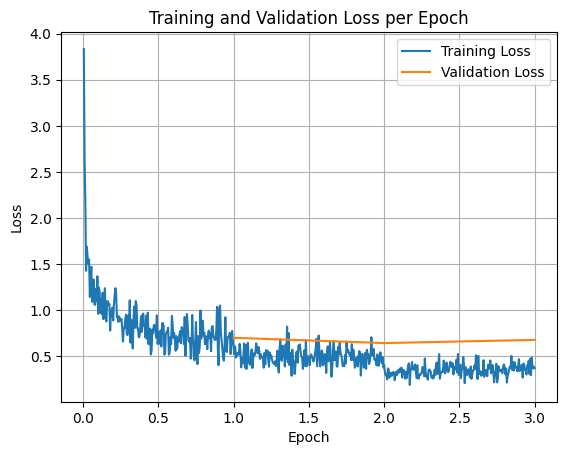

In [ ]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

## Make Inference

We've now fine-tuned our own Gemma 3 270M to do a specific task, let's load it back in and see how it performs.

In [ ]:
# Load the fine-tuned model and see how it goes
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

In [ ]:
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

Device set to use cuda:0


In [ ]:
dataset["test"]

Dataset({
    features: ['input', 'output', 'messages'],
    num_rows: 200
})

Let's now perform inference with our fine-tuned model on a random sample from the test dataset (our model has never seen these samples).

In [ ]:
# Get a random sample
random_test_idx = get_random_idx(dataset["test"])
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_test_sample["messages"][:1],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the fine-tuned model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Design a diagram representing the workflow of a disaster recovery plan implementation. Ensure it includes steps such as risk assessment, plan development, testing, recovery operations, and post-recovery assessment.<end_of_turn>
<start_of_turn>model


[INFO] Output:
graph TD;
    A[Risk Assessment] --> B[Plan Development];
    B --> C[Testing];
    C --> D[Recovery Operations];
    D --> E[Post-Recovery Assessment];


In [ ]:
print(random_test_sample["output"])

graph TD;
    A[Risk Assessment] --> B[Plan Development];
    B --> C[Testing];
    C --> D[Recovery Operations];
    D --> E[Post-Recovery Assessment];


## Model Size

In [ ]:
def get_model_num_params(model):
    """
    Returns the number of trainable, non-trainable and total parameters of a PyTorch model.
    """
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_params = trainable_params + non_trainable_params
    return {"trainable_params": trainable_params,
            "non_trainable_params": non_trainable_params,
            "total_params": total_params}

# Get parameters of our fine-tuned model
model_params = get_model_num_params(loaded_model)
print(f"Trainable parameters: {model_params['trainable_params']:,}")
print(f"Non-trainable parameters: {model_params['non_trainable_params']:,}")
print(f"Total parameters: {model_params['total_params']:,}")

Trainable parameters: 268,098,176
Non-trainable parameters: 0
Total parameters: 268,098,176


In [ ]:
# Our model is 270M parameters, GPT-OSS-120B is 120B parameters
120_000_000_000 / 270_000_000

444.44444444444446

By fine-tuning Gemma 3 270M we distill the capabilities of a 120B parameter model into a model 444x smaller.

## Uploading to the HF Hub

We can upload our fine-tuned model to the Hugging Face Hub so other people can use it and test it out.

First, let's load it in ourselves and confirm it works how we'd like it to.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import pipeline

MODEL_PATH = "./checkpoint_models/"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH
)

# Create a pipeline from the loaded model
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Test the loaded model on raw text (this won't work as well as formatted text)
test_input_message = """
Design a composite structure diagram for a car navigation system.
Include components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.
"""
loaded_model_pipeline(test_input_message)

The module name  (originally ) is not a valid Python identifier. Please rename the original module to avoid import issues.
The tokenizer you are loading from './checkpoint_models/' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Device set to use cuda:0


[{'generated_text': '\nDesign a composite structure diagram for a car navigation system.\nInclude components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.\n'}]

Let's create a helper function to format our input text into message format.

In [ ]:
def format_message(input):
    return [{"role": "user", "content": input}]

input_formatted = format_message(input=test_input_message)
input_formatted

[{'role': 'user',
  'content': '\nDesign a composite structure diagram for a car navigation system.\nInclude components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.\n'}]

Now we can turn it into a prompt with our `tokenizer` and the `apply_chat_template` method.

In [ ]:
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=input_formatted,
                                                                   tokenize=False,
                                                                   add_generation_prompt=True)

input_prompt

'<bos><start_of_turn>user\nDesign a composite structure diagram for a car navigation system.\nInclude components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.<end_of_turn>\n<start_of_turn>model\n'

Beautiful! Time to run our fine-tuned model!

In [ ]:
loaded_model_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                             max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{loaded_model_outputs[0]['generated_text'][len(input_prompt):]}")

[INFO] Input:
<bos><start_of_turn>user
Design a composite structure diagram for a car navigation system.
Include components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.<end_of_turn>
<start_of_turn>model


[INFO] Output:
composite
    A[GPS Module] --> B[Display Unit]
    B --> C[Control Module]
    B --> D[Control Panel]
    B --> E[Navigation System]
    B --> F[Database]
    B --> G[API Gateway]
    B --> H[Controller]


Okay let's make another helper function to predict on any given sample input.

We'll also return the inference time of our model so we can see how long things take.

In [ ]:
import time

def pred_on_text(input_text):
    start_time = time.time()

    raw_output = loaded_model_pipeline(text_inputs=[{"role": "user",
                                                    "content": input_text}],
                                       max_new_tokens=256,
                                       disable_compile=True)
    end_time = time.time()
    total_time = round(end_time - start_time, 4)

    generated_text = raw_output[0]["generated_text"][1]["content"]

    return generated_text, raw_output, total_time

pred_on_text(input_text=test_input_message)

('composite\n  A[GPS Module] --> B[Display Unit]\n  B --> C[Control Module]\n  C --> D[Control Panel]\n  D --> E[Sensor Network]\n  E --> A',
 [{'generated_text': [{'role': 'user',
     'content': '\nDesign a composite structure diagram for a car navigation system.\nInclude components such as GPS Module, Display Unit, Control Module, and illustrate how these components interact internally.\n'},
    {'role': 'assistant',
     'content': 'composite\n  A[GPS Module] --> B[Display Unit]\n  B --> C[Control Module]\n  C --> D[Control Panel]\n  D --> E[Sensor Network]\n  E --> A'}]}],
 4.3156)

Nice! Looks like our model is working well enough (of course we could always improve it over time with more testing and different samples).

Let's upload it to the Hugging Face Hub. We can do so using the [`huggingface_hub`](https://huggingface.co/docs/huggingface_hub/en/index) library.

In [ ]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# Give our model a name (this is in the format [Hugging Face Username]/[Target Model Name]
repo_id = "MrObiKenobi/mermaid-gemma-3-270m-it"

# Create the repo
create_repo(repo_id,
            repo_type="model",
            exist_ok=True)

# Upload the entire model folder containing our model files
api.upload_folder(
    folder_path="./checkpoint_models/",
    repo_id=repo_id,
    repo_type="model"
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._models/model.safetensors:   0%|          |  604kB /  536MB            

  ...nt_models/tokenizer.model: 100%|##########| 4.69MB / 4.69MB            

  ...int_models/tokenizer.json:  50%|#####     | 16.7MB / 33.4MB            

  ...700325.609a3bb50941.883.0:   6%|6         | 14.9kB /  236kB            

  ..._models/training_args.bin:   6%|6         |   395B / 6.29kB            

CommitInfo(commit_url='https://huggingface.co/MrObiKenobi/Mermaid-gemma-3-270m-it/commit/1b3531b1b2a8b04aa4fe963e5903b52baebfcd42', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1b3531b1b2a8b04aa4fe963e5903b52baebfcd42', pr_url=None, repo_url=RepoUrl('https://huggingface.co/MrObiKenobi/Mermaid-gemma-3-270m-it', endpoint='https://huggingface.co', repo_type='model', repo_id='MrObiKenobi/Mermaid-gemma-3-270m-it'), pr_revision=None, pr_num=None)

Woohoo! Our model is officially on the Hugging Face Hub.

Now not only can we redownload it and use it again, others can download it and use it for themselves (of course you can make the model private if you like too).

## [Bonus] Gradio demo

Right now our model seems to be working quite well for our specific use case. However, it takes some coding to be able to use it. What if we wanted to allow someone who wasn't familiar with programming to try it out?

To do so, we can turn our model into a [**Gradio demo**](https://www.gradio.app) and upload it to [**Hugging Face Spaces**](https://huggingface.co/spaces) (a place to share all kinds of small applications). Gradio allows us to turn our model into an easy to use and sharable demo anyone can try.


To create a sharable demo, we'll need the following files:

- `app.py` - Entry point for our app, all of our application code will go in here.
- `README.md` - Tells people what our app does.
- `requirements.txt` - Tells Hugging Face Spaces what our app requires.

## [Bonus] Batched inference

Right now our model only inferences on one sample at a time but as is the case with many machine learning models, we could **perform inference on multiple samples** (also referred to as a batch) to significantly **improve throughput**.

> *Throughput* → how many samples/sec you process
>
> *Latency* → how long one request takes
>
> *Batching* → improves throughput, may increase latency

The number of samples you can predict on at once will depend on a few **factors**:
-  The size of your model (e.g. if your model is quite large, it may only be able to predict on 1 sample at time)
- The size of your compute VRAM (e.g. if your compute VRAM is already saturated, add multiple samples at a time may result in errors)
- The size of your samples (if one of your samples is 100x the size of others, this may cause errors with batched inference)

To **find an optimal batch size** for our setup, we can loop through different batch sizes and measure the throughput for each batch size.

Why do we do this?
- It's hard to tell the ideal batch size ahead of time.
- So we experiment from say 1, 2, 4, 8, 16, 32, 64 batch sizes and see which performs best.
- Just because we may get a speed up from using batch size 8, doesn't mean 64 will be better.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("ibm-research/MermaidSeqBench")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

# Normalize dataset column names
dataset = dataset.rename_columns({
    "input_prompt": "input",
    "expected_output": "output",
})

def sample_to_conversation(sample):
    return {
        "messages": [
            {"role": "user", "content": sample["input"]},
            {"role": "system", "content": sample["output"]}
        ]
    }

# Map our sample_to_conversation function to dataset
dataset = dataset.map(sample_to_conversation,
                      batched=False)

dataset

README.md: 0.00B [00:00, ?B/s]

data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/132 [00:00<?, ? examples/s]

[INFO] Number of samples in the dataset: 132


Map:   0%|          | 0/132 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['nl_task_title', 'nl_task_desc', 'input', 'output', 'messages'],
        num_rows: 132
    })
})

In [ ]:
# Step 1: Need to turn our samples into batches (e.g. lists of samples)
print(f"[INFO] Formatting test samples into list prompts...")
test_input_prompts = [
    loaded_model_pipeline.tokenizer.apply_chat_template(
        item["messages"][:1],
        tokenize=False,
        add_generation_prompt=True
    )
    for item in dataset["train"]
]
print(f"[INFO] Number of test sample prompts: {len(test_input_prompts)}")
test_input_prompts[0]

[INFO] Formatting test samples into list prompts...
[INFO] Number of test sample prompts: 132


'<bos><start_of_turn>user\nGenerate a valid, syntactically correct MermaidJS UML\nsequence diagram based on the provided structured input:\n\nInput Format:\n- Purpose: Description of the diagram\n- Main Components: List of involved components\n- Interactions: Sequence of interactions\n\nGeneral Guidelines:\n- Identify interactions between the Main Components, distinguishing requests (->>) and responses (-->>). \n- Structure participants in this order: Users -> Frontend (Mobile/Web) -> Backend (BFF, Middleware, SOR, DB).\n- Determine all the alternate cases needed, if-else, alt, and make sure they are all covered.\n- Make sure there is a response to every request.\n- Format API calls as REST API (e.g., `GET /Workorder(params)`, `POST /Workorder(params)`).\n- Handle alternate flows (if, if-else, nested conditions) per MermaidJS syntax.\n- Ensure syntax correctness, covering all responses, error scenarios, and system failures.\n- Use activation (`activate` actor) and deactivation (`deacti

In [ ]:
# Step 2: Need to perform batched inference and time each step
import time
from tqdm.auto import tqdm

all_outputs = []

# Let's write a list of batch sizes to test
chunk_sizes_to_test = [1, 4, 8, 16] # ... 32, 64, 128
timing_dict = {}

# Loop through each batch size and time the inference
for CHUNK_SIZE in chunk_sizes_to_test:
    print(f"[INFO] Making predictions with batch size: {CHUNK_SIZE}")
    start_time = time.time()

    for chunk_number in tqdm(range(round(len(test_input_prompts) / CHUNK_SIZE))):
        batched_inputs = test_input_prompts[(CHUNK_SIZE * chunk_number): CHUNK_SIZE * (chunk_number + 1)]
        batched_outputs = loaded_model_pipeline(text_inputs=batched_inputs,
                                                batch_size=CHUNK_SIZE,
                                                max_new_tokens=256,
                                                disable_compile=True)

        all_outputs += batched_outputs

    end_time = time.time()
    total_time = end_time - start_time
    timing_dict[CHUNK_SIZE] = total_time
    print()
    print(f"[INFO] Total time for batch size {CHUNK_SIZE}: {total_time:.2f}s")
    print("="*80 + "\n\n")

[INFO] Making predictions with batch size: 1


  0%|          | 0/132 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



[INFO] Total time for batch size 1: 534.67s


[INFO] Making predictions with batch size: 4


  0%|          | 0/33 [00:00<?, ?it/s]


[INFO] Total time for batch size 4: 208.87s


[INFO] Making predictions with batch size: 8


  0%|          | 0/16 [00:00<?, ?it/s]


[INFO] Total time for batch size 8: 110.92s


[INFO] Making predictions with batch size: 16


  0%|          | 0/8 [00:00<?, ?it/s]


[INFO] Total time for batch size 16: 73.36s




Batched inference complete! Let's make a plot comparing different batch sizes.

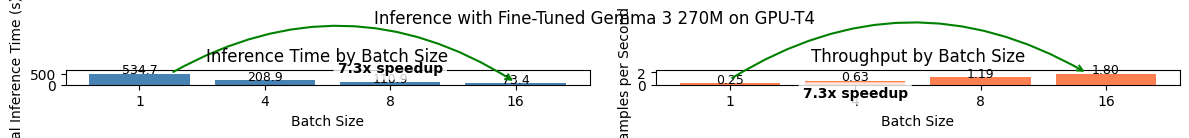

In [ ]:
import matplotlib.pyplot as plt

# Data
data = timing_dict

total_samples = len(dataset["train"])

batch_sizes = list(data.keys())
inference_times = list(data.values())
samples_per_second = [total_samples / time for bs, time in data.items()]

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left plot: Total Inference Time ---
ax1.bar([str(bs) for bs in batch_sizes], inference_times, color='steelblue')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Total Inference Time (s)')
ax1.set_title('Inference Time by Batch Size')

for i, v in enumerate(inference_times):
    ax1.text(i, v + 1, f'{v:.1f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Left) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val = max(inference_times)
end_val = min(inference_times)
start_idx = inference_times.index(start_val)
end_idx = inference_times.index(end_val)

speedup = start_val / end_val

# 2. Draw Arrow (No Text)
# connectionstyle "rad=-0.3" arcs the arrow upwards
ax1.annotate("",
             xy=(end_idx, end_val+(0.5*end_val)),
             xytext=(start_idx+0.25, start_val+10),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x = (start_idx + end_idx) / 2
# Place text slightly above the highest point of the two bars
text_y = max(start_val, end_val) + (max(inference_times) * 0.1)

ax1.text(mid_x+0.5, text_y-150, f"{speedup:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax1.set_ylim(0, max(inference_times) * 1.35) # Increase headroom for text


# --- Right plot: Samples per Second ---
ax2.bar([str(bs) for bs in batch_sizes], samples_per_second, color='coral')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Samples per Second')
ax2.set_title('Throughput by Batch Size')

for i, v in enumerate(samples_per_second):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9)

# --- ARROW LOGIC (Right) ---
# 1. Identify Start (Slowest) and End (Fastest)
start_val_t = min(samples_per_second)
end_val_t = max(samples_per_second)
start_idx_t = samples_per_second.index(start_val_t)
end_idx_t = samples_per_second.index(end_val_t)

speedup_t = end_val_t / start_val_t

# 2. Draw Arrow (No Text)
ax2.annotate("",
             xy=(end_idx_t-(0.05*end_idx_t), end_val_t+(0.025*end_val_t)),
             xytext=(start_idx_t, start_val_t+0.6),
             arrowprops=dict(arrowstyle="->", color='green', lw=1.5, connectionstyle="arc3,rad=-0.3"))

# 3. Place Text at Midpoint
mid_x_t = (start_idx_t + end_idx_t) / 2
text_y_t = max(start_val_t, end_val_t) + (max(samples_per_second) * 0.1)

ax2.text(mid_x_t-0.5, text_y_t-4.5, f"{speedup_t:.1f}x speedup",
         ha='center', va='bottom', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))

ax2.set_ylim(0, max(samples_per_second) * 1.35) # Increase headroom

plt.suptitle("Inference with Fine-Tuned Gemma 3 270M on GPU-T4")
plt.tight_layout()
plt.savefig('inference_benchmark.png', dpi=150)
plt.show()

In [ ]:
samples_per_second = round(len(dataset["train"]) / min(timing_dict.values()), 2)
seconds_in_a_day = 86_400
samples_per_day = seconds_in_a_day * samples_per_second

print(f"[INFO] Number of samples per second: {samples_per_second} | Number of samples per day: {samples_per_day}")

[INFO] Number of samples per second: 1.8 | Number of samples per day: 155520.0


## [Bonus] Performing evaluations on our model

We can evaluate our model directly against the original labels from `gpt-oss-120b` and see how it stacks up.

1. Design metrics to compare ground truth with actual responses.
2. Collect samples which are different to the ground truth would allow us to further explore where our model needs improvements.

## Next steps

There are several avenues we could approach next...

1. Improve the data sampling - if our model makes mistakes, could we improve the input data? For example, more samples on certain tasks where the model is weaker.

2. Quantisation - right now our model is ~500MB, could we make this smaller with the help of INT8 quantisation? (this could also help speed up inference time).

3. Output compression - our output is compressed to mermaid-like format, but is there a better compression option to generate even less tokens?

4. Test the model on a large unseen sample and randomly inspect them to find failure cases to boost the model performance.

---